In [2]:
import os
import json

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/FinalDNN'
DATASET_DIR = f'{PROJECT_DIR}/datasets'
MODEL_DIR   = f'{PROJECT_DIR}/models'
RESULTS_DIR = f'{PROJECT_DIR}/results'

for d in [PROJECT_DIR, DATASET_DIR, MODEL_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Drive monté")

# Configurer Kaggle
KAGGLE_USERNAME = "r1ppxrr"
KAGGLE_KEY      = "c9bae231d5eeaf2371400614d7b95196"

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)

!chmod 600 ~/.kaggle/kaggle.json
!pip install kaggle -q

print("Kaggle configuré")

Mounted at /content/drive
Drive monté
Kaggle configuré


In [3]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import gc
import psutil
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import LabelEncoder, RobustScaler
from sklearn.metrics            import (classification_report,
                                         confusion_matrix,
                                         accuracy_score,
                                         f1_score,
                                         roc_auc_score,
                                         roc_curve)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow                 import keras
from tensorflow.keras           import layers, regularizers, callbacks
from tensorflow.keras.utils     import to_categorical

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

def check_ram():
    ram  = psutil.virtual_memory()
    free = ram.available / 1e9
    used = ram.used / 1e9
    tot  = ram.total / 1e9
    print(f"RAM : {used:.1f}GB utilisés | {free:.1f}GB libres | {tot:.1f}GB total")
    if free < 1.5:
        gc.collect()

check_ram()

RAM : 1.3GB utilisés | 12.0GB libres | 13.6GB total


In [4]:
import os
import glob

# Vérifier si déjà dans Drive
csv_in_drive = glob.glob(f'{DATASET_DIR}/*.csv')

if csv_in_drive:
    print(f"Dataset déjà dans Drive ({len(csv_in_drive)} fichiers)")
    for f in csv_in_drive:
        size = os.path.getsize(f) / 1e6
        print(f"{os.path.basename(f)} → {size:.1f} MB")

else:

    os.makedirs('/content/cicids_raw', exist_ok=True)

    # Télécharger
    !kaggle datasets download \
        -d chethuhn/network-intrusion-dataset \
        -p /content/cicids_raw -q


    # Décompresser uniquement le fichier Wednesday
    import zipfile
    zip_path = '/content/cicids_raw/network-intrusion-dataset.zip'

    with zipfile.ZipFile(zip_path, 'r') as z:
        all_csv = [f for f in z.namelist() if f.endswith('.csv')]
        print(f"\n   Fichiers disponibles ({len(all_csv)}) :")
        for f in all_csv:
            size = z.getinfo(f).file_size / 1e6
            print(f"{f} → {size:.1f} MB")

        # Extraire Wednesday
        target = next(
            (f for f in all_csv if 'Wednesday' in f or 'wednesday' in f),
            all_csv[0]
        )
        print(f"\n Extraction : {target}")
        z.extract(target, '/content/cicids_raw/')

    # Copier dans Drive
    extracted = glob.glob('/content/cicids_raw/*.csv')
    for f in extracted:
        dest = f'{DATASET_DIR}/{os.path.basename(f)}'
        !cp "{f}" "{dest}"
        print(f"   💾 Sauvegardé dans Drive : {os.path.basename(f)}")

    # Nettoyage
    !rm -rf /content/cicids_raw
    gc.collect()
    print("Dataset terminer et dans Drive")

Dataset déjà dans Drive (1 fichiers)
Wednesday-workingHours.pcap_ISCX.csv → 225.2 MB


In [5]:
import pandas as pd
import numpy as np
import gc
import glob
import os

# Fonction de mapping des labels
def map_label(lbl):
    lbl = str(lbl).upper().strip()
    if 'BENIGN'   in lbl:                   return 'BENIGN'
    if 'DOS'      in lbl or 'DDOS' in lbl:  return 'DoS'
    if 'PORTSCAN' in lbl or 'SCAN' in lbl:  return 'Probe'
    if 'BRUTE'    in lbl or 'FTP'  in lbl \
       or 'SSH'   in lbl:                   return 'R2L'
    if 'BOT'      in lbl:                   return 'Bot'
    if 'WEB'      in lbl or 'SQL'  in lbl \
       or 'XSS'   in lbl:                   return 'WebAttack'
    if 'INFILTR'  in lbl:                   return 'U2R'
    if 'HEART'    in lbl:                   return 'DoS'
    return 'Other'

# Trouver le fichier CSV
csv_files = glob.glob(f'{DATASET_DIR}/*.csv')
if not csv_files:
    csv_files = glob.glob('/content/cicids_raw/*.csv')

print(f"Fichier trouvé : {os.path.basename(csv_files[0])}")

# Lecture par chunks ANTI-CRASH
CHUNK_SIZE  = 50000    # 50K lignes par chunk
MAX_LIGNES  = 200000   # 200K lignes maximum

print(f"\n Lecture par chunks de {CHUNK_SIZE:,} lignes.")
print(f" Maximum : {MAX_LIGNES:,} lignes")

frames = []
total  = 0

for i, chunk in enumerate(pd.read_csv(csv_files[0],
                                        chunksize=CHUNK_SIZE,
                                        low_memory=False)):
    # Nettoyer les noms de colonnes
    chunk.columns = chunk.columns.str.strip()

    # Remplacer infini et NaN
    chunk.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Trouver la colonne label
    lbl_col = next(
        (c for c in chunk.columns if 'label' in c.lower()),
        None
    )
    if lbl_col is None:
        continue

    # Mapper les labels
    chunk[lbl_col] = chunk[lbl_col].apply(map_label)
    chunk.rename(columns={lbl_col: 'label'}, inplace=True)

    frames.append(chunk)
    total += len(chunk)
    print(f" Chunk {i+1} : {total:,} lignes chargées")

    if total >= MAX_LIGNES:
        print(f"  Limite {MAX_LIGNES:,} atteinte → arrêt")
        break

# Fusionner tous les chunks
df = pd.concat(frames, ignore_index=True)
del frames
gc.collect()

print(f"\n Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"\n Distribution des labels :")
print(df['label'].value_counts())

check_ram()

Fichier trouvé : Wednesday-workingHours.pcap_ISCX.csv

 Lecture par chunks de 50,000 lignes.
 Maximum : 200,000 lignes
 Chunk 1 : 50,000 lignes chargées
 Chunk 2 : 100,000 lignes chargées
 Chunk 3 : 150,000 lignes chargées
 Chunk 4 : 200,000 lignes chargées
  Limite 200,000 atteinte → arrêt

 Dataset chargé : 200,000 lignes × 79 colonnes

 Distribution des labels :
label
DoS       129971
BENIGN     70029
Name: count, dtype: int64
RAM : 1.5GB utilisés | 11.7GB libres | 13.6GB total


In [6]:
import numpy as np
import gc
import psutil
import tensorflow as tf
from sklearn.preprocessing   import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils  import to_categorical

# Libérer la RAM
gc.collect()
tf.keras.backend.clear_session()
check_ram()

# ── A. Séparer features et labels ───────────────────────────────
print("\n[A] Séparation features / labels")

drop_cols = ['label']
feat_cols = [
    c for c in df.columns
    if c not in drop_cols
    and df[c].dtype in [np.float64, np.float32, np.int64, np.int32]
]

# float32 = 2× moins de RAM
X_raw = df[feat_cols].values.astype(np.float32)
y_raw = df['label'].values.copy()

# Supprimer df → libère RAM immédiatement
del df
gc.collect()

print(f"   Features brutes : {X_raw.shape[1]}")
print(f"   Échantillons    : {X_raw.shape[0]:,}")
check_ram()

# ── B. Nettoyage ─────────────────────────────────────────────────
print("\n[B] Nettoyage...")

# Infini → NaN
X_raw = np.where(np.isinf(X_raw), np.nan, X_raw)
X_raw = X_raw.astype(np.float32)

# NaN → médiane de chaque colonne
col_medians = np.nanmedian(X_raw, axis=0)
nan_mask    = np.isnan(X_raw)
for j in range(X_raw.shape[1]):
    X_raw[nan_mask[:, j], j] = col_medians[j]

# Supprimer colonnes constantes (std = 0)
std_vals       = np.std(X_raw, axis=0)
good_cols      = std_vals > 0
X_raw          = X_raw[:, good_cols]
feat_cols_kept = [feat_cols[i] for i in range(len(feat_cols)) if good_cols[i]]

gc.collect()
print(f" Features après nettoyage : {X_raw.shape[1]}")
check_ram()

# ── C. Encoder les labels ────────────────────────────────────────
print("\n[C] Encodage des labels...")

le          = LabelEncoder()
y_enc       = le.fit_transform(y_raw)
N_CLASSES   = len(le.classes_)
CLASS_NAMES = list(le.classes_)

del y_raw
gc.collect()

print(f" Nombre de classes : {N_CLASSES}")
for i, cls in enumerate(CLASS_NAMES):
    count = int((y_enc == i).sum())
    pct   = count / len(y_enc) * 100
    print(f"      Classe {i} — {cls:<12} : {count:,} ({pct:.1f}%)")

# ── D. Sélection des meilleures features ─────────────────────────
print("\n[D] Sélection des meilleures features")

N_TOP = 40  # 40 features suffisent pour un excellent DNN

# Variance filter : rapide et efficace
# → les features avec grande variance contiennent plus d'information
variances   = np.var(X_raw, axis=0)
top_indices = np.argsort(variances)[::-1][:N_TOP]
X_selected  = X_raw[:, top_indices].astype(np.float32)
FEAT_NAMES  = [feat_cols_kept[i] for i in top_indices]
K           = X_selected.shape[1]

del X_raw
gc.collect()

print(f"   Features sélectionnées : {K}")
print(f"   Top 5 features : {FEAT_NAMES[:5]}")
check_ram()

# ── E. Split train / val / test ──────────────────────────────────
print("\n[E] Split des données...")

# Split 1 : 85% train+val / 15% test
X_tr, X_te, y_tr, y_te = train_test_split(
    X_selected, y_enc,
    test_size=0.15,
    random_state=SEED,
    stratify=y_enc
)

# Split 2 : 88% train / 12% val
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr,
    test_size=0.12,
    random_state=SEED,
    stratify=y_tr
)

del X_selected, y_enc
gc.collect()

print(f"   Train      : {X_tr.shape[0]:,} échantillons")
print(f"   Validation : {X_val.shape[0]:,} échantillons")
print(f"   Test       : {X_te.shape[0]:,} échantillons")

# ── F. Normalisation RobustScaler ────────────────────────────────
print("\n[F] Normalisation...")

scaler = RobustScaler()
X_tr   = scaler.fit_transform(X_tr).astype(np.float32)
X_val  = scaler.transform(X_val).astype(np.float32)
X_te   = scaler.transform(X_te).astype(np.float32)

print("Normalisation terminée")

# ── G. One-Hot Encoding ──────────────────────────────────────────
print("\n[G] One-Hot Encoding des labels...")

y_tr_cat  = to_categorical(y_tr,  N_CLASSES)
y_val_cat = to_categorical(y_val, N_CLASSES)
y_te_cat  = to_categorical(y_te,  N_CLASSES)

# ── Résumé ───────────────────────────────────────────────────────
print(f"\n{'─'*45}")
print(f"  X_train : {X_tr.shape}  →  y : {y_tr_cat.shape}")
print(f"  X_val   : {X_val.shape}  →  y : {y_val_cat.shape}")
print(f"  X_test  : {X_te.shape}  →  y : {y_te_cat.shape}")
print(f"  Classes : {CLASS_NAMES}")
check_ram()

RAM : 1.6GB utilisés | 11.7GB libres | 13.6GB total

[A] Séparation features / labels
   Features brutes : 78
   Échantillons    : 200,000
RAM : 1.6GB utilisés | 11.6GB libres | 13.6GB total

[B] Nettoyage...
 Features après nettoyage : 68
RAM : 1.6GB utilisés | 11.7GB libres | 13.6GB total

[C] Encodage des labels...
 Nombre de classes : 2
      Classe 0 — BENIGN       : 70,029 (35.0%)
      Classe 1 — DoS          : 129,971 (65.0%)

[D] Sélection des meilleures features
   Features sélectionnées : 40
   Top 5 features : ['Fwd IAT Total', 'Flow Duration', 'Idle Max', 'Idle Min', 'Fwd IAT Max']
RAM : 1.6GB utilisés | 11.6GB libres | 13.6GB total

[E] Split des données...
   Train      : 149,600 échantillons
   Validation : 20,400 échantillons
   Test       : 30,000 échantillons

[F] Normalisation...
Normalisation terminée

[G] One-Hot Encoding des labels...

─────────────────────────────────────────────
  X_train : (149600, 40)  →  y : (149600, 2)
  X_val   : (20400, 40)  →  y : (20400

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import gc

gc.collect()

def build_dnn(input_dim, n_classes):
    """
    Construit le DNN pour la détection d'intrusions.
    input_dim : nombre de features (40)
    n_classes  : nombre de classes (7)
    """

    inputs = keras.Input(shape=(input_dim,), name='input')

    # ══ BLOC 1 : 256 neurones ═══════════════════════════════════
    x = layers.Dense(
            256,
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(1e-4),
            name='dense_1'
        )(inputs)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu', name='relu_1')(x)
    x = layers.Dropout(0.40, name='drop_1')(x)

    # ══ BLOC 2 : 256 neurones ═══════════════════════════════════
    x = layers.Dense(
            256,
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(1e-4),
            name='dense_2'
        )(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Activation('relu', name='relu_2')(x)
    x = layers.Dropout(0.35, name='drop_2')(x)

    # ══ BLOC 3 : 128 neurones ═══════════════════════════════════
    x = layers.Dense(
            128,
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(1e-4),
            name='dense_3'
        )(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.Activation('relu', name='relu_3')(x)
    x = layers.Dropout(0.30, name='drop_3')(x)

    # ══ BLOC 4 : 64 neurones ════════════════════════════════════
    x = layers.Dense(
            64,
            kernel_initializer='he_normal',
            kernel_regularizer=regularizers.l2(1e-4),
            name='dense_4'
        )(x)
    x = layers.BatchNormalization(name='bn_4')(x)
    x = layers.Activation('relu', name='relu_4')(x)
    x = layers.Dropout(0.20, name='drop_4')(x)

    # ══ SORTIE : Softmax ════════════════════════════════════════
    outputs = layers.Dense(
        n_classes,
        activation='softmax',
        name='output'
    )(x)

    model = keras.Model(inputs, outputs, name='IDS_DNN')
    return model

# Construire le modèle
model_dnn = build_dnn(K, N_CLASSES)
model_dnn.summary()

total_params = model_dnn.count_params()
print(f"\nModèle DNN construit")
print(f"   Paramètres totaux : {total_params:,}")
print(f"   Input shape       : ({K},)")
print(f"   Output shape      : ({N_CLASSES},) → {CLASS_NAMES}")

Model: "IDS_DNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_4 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_4 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,386 (470.26 KB)

 Trainable params: 118,978 (464.76 KB)

 Non-trainable params: 1,408 (5.50 KB)


Modèle DNN construit
   Paramètres totaux : 120,386
   Input shape       : (40,)
   Output shape      : (2,) → ['BENIGN', 'DoS']


In [8]:
# ═══ ENTRAÎNEMENT DNN ═══

import gc
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import callbacks
from sklearn.utils.class_weight import compute_class_weight

# Libérer la RAM
gc.collect()
tf.keras.backend.clear_session()

# Reconstruire le modèle après clear_session
model_dnn = build_dnn(K, N_CLASSES)
print("Modèle reconstruit")

# ── Class weights ────────────────────────────────────────────────
cw = compute_class_weight(
    'balanced',
    classes=np.unique(y_tr),
    y=y_tr
)
class_weight_dict = dict(enumerate(cw))
print("\n Class weights :")
for i, (cls, w) in enumerate(zip(CLASS_NAMES, cw)):
    print(f"   {cls:<12} : {w:.3f}")

# ── Paramètres ───────────────────────────────────────────────────
EPOCHS     = 50
BATCH_SIZE = 256
LR         = 1e-3   # ← LR fixe (float) pas de schedule

print(f"\n Époques    : {EPOCHS}")
print(f"   Batch size : {BATCH_SIZE}")
print(f"   LR         : {LR}")

# ── Compilation ──────────────────────────────────────────────────
# LR = float simple → compatible avec ReduceLROnPlateau
model_dnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
print("Modèle compilé")

# ── Callbacks ────────────────────────────────────────────────────
BEST_MODEL = f'{MODEL_DIR}/best_dnn.keras'

cb_list = [
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    # ReduceLROnPlateau fonctionne UNIQUEMENT avec LR float
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-8,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=BEST_MODEL,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    ),
    callbacks.LambdaCallback(
        on_epoch_end=lambda epoch, logs: gc.collect()
    )
]

# ── tf.data.Dataset ──────────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_tr, y_tr_cat)
).shuffle(
    buffer_size=5000,
    seed=42
).batch(BATCH_SIZE
).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val_cat)
).batch(BATCH_SIZE
).prefetch(AUTOTUNE)

print("Dataset prêt")
check_ram()

# ── Entraînement ─────────────────────────────────────────────────
print(f"\nEntraînement DNN")

history = model_dnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=cb_list,
    verbose=1
)

del train_ds, val_ds
gc.collect()

print(f"\nEntraînement terminé !")
print(f"Modèle : {BEST_MODEL}")
check_ram()


Modèle reconstruit

 Class weights :
   BENIGN       : 1.428
   DoS          : 0.769

 Époques    : 50
   Batch size : 256
   LR         : 0.001
Modèle compilé
Dataset prêt
RAM : 2.0GB utilisés | 11.2GB libres | 13.6GB total

Entraînement DNN
Epoch 1/50
585/585 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.6826 - auc: 0.7465 - loss: 0.7270 - precision: 0.6826 - recall: 0.6826 - val_accuracy: 0.4828 - val_auc: 0.6583 - val_loss: 0.7249 - val_precision: 0.4828 - val_recall: 0.4828 - learning_rate: 0.0010
Epoch 2/50
585/585 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7138 - auc: 0.7974 - loss: 0.6454 - precision: 0.7138 - recall: 0.7138 - val_accuracy: 0.4775 - val_auc: 0.6361 - val_loss: 0.7585 - val_precision: 0.4775 - val_recall: 0.4775 - learning_rate: 0.0010
Epoch 3/50
585/585 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7187 - auc: 0.8107 - loss: 0.6176 - precision: 0.7187 - recall: 0.7187 - val_accuracy: 0.4780 - val_auc: 0.6349 - val_loss: 0.7752 - val_precision: 0.4780 - 

In [9]:
import numpy as np
import gc
import tensorflow as tf
from sklearn.metrics import (accuracy_score, f1_score,
                              roc_auc_score, classification_report,
                              confusion_matrix)
from tensorflow.keras.utils import to_categorical

gc.collect()

print("  Évaluation sur le jeu de test")

# Prédictions
y_pred_proba = model_dnn.predict(X_te, batch_size=256, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

# Métriques globales
acc  = accuracy_score(y_te, y_pred)
f1_w = f1_score(y_te, y_pred, average='weighted', zero_division=0)
f1_m = f1_score(y_te, y_pred, average='macro',    zero_division=0)

# AUC-ROC
try:
    y_te_bin   = to_categorical(y_te, N_CLASSES)
    auc_list   = []
    for i in range(N_CLASSES):
        if len(np.unique(y_te_bin[:, i])) > 1:
            auc_list.append(
                roc_auc_score(y_te_bin[:, i], y_pred_proba[:, i])
            )
    auc_mean = float(np.mean(auc_list))
except Exception:
    auc_mean = 0.0

# Affichage
print(f"\n  MÉTRIQUES GLOBALES :")
print(f"  Accuracy          : {acc*100:.2f} %")
print(f"  F1-Score Weighted : {f1_w*100:.2f} %")
print(f"  F1-Score Macro    : {f1_m*100:.2f} %")
print(f"  AUC-ROC moyen     : {auc_mean:.4f}")

print(f"\n  RAPPORT PAR CLASSE :")
print(classification_report(
    y_te, y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

# Sauvegarder les métriques
CM = confusion_matrix(y_te, y_pred)

  Évaluation sur le jeu de test

  MÉTRIQUES GLOBALES :
  Accuracy          : 59.68 %
  F1-Score Weighted : 58.17 %
  F1-Score Macro    : 59.32 %
  AUC-ROC moyen     : 0.8677

  RAPPORT PAR CLASSE :
              precision    recall  f1-score   support

      BENIGN     0.4643    0.9862    0.6314     10504
         DoS     0.9811    0.3870    0.5550     19496

    accuracy                         0.5968     30000
   macro avg     0.7227    0.6866    0.5932     30000
weighted avg     0.8002    0.5968    0.5817     30000



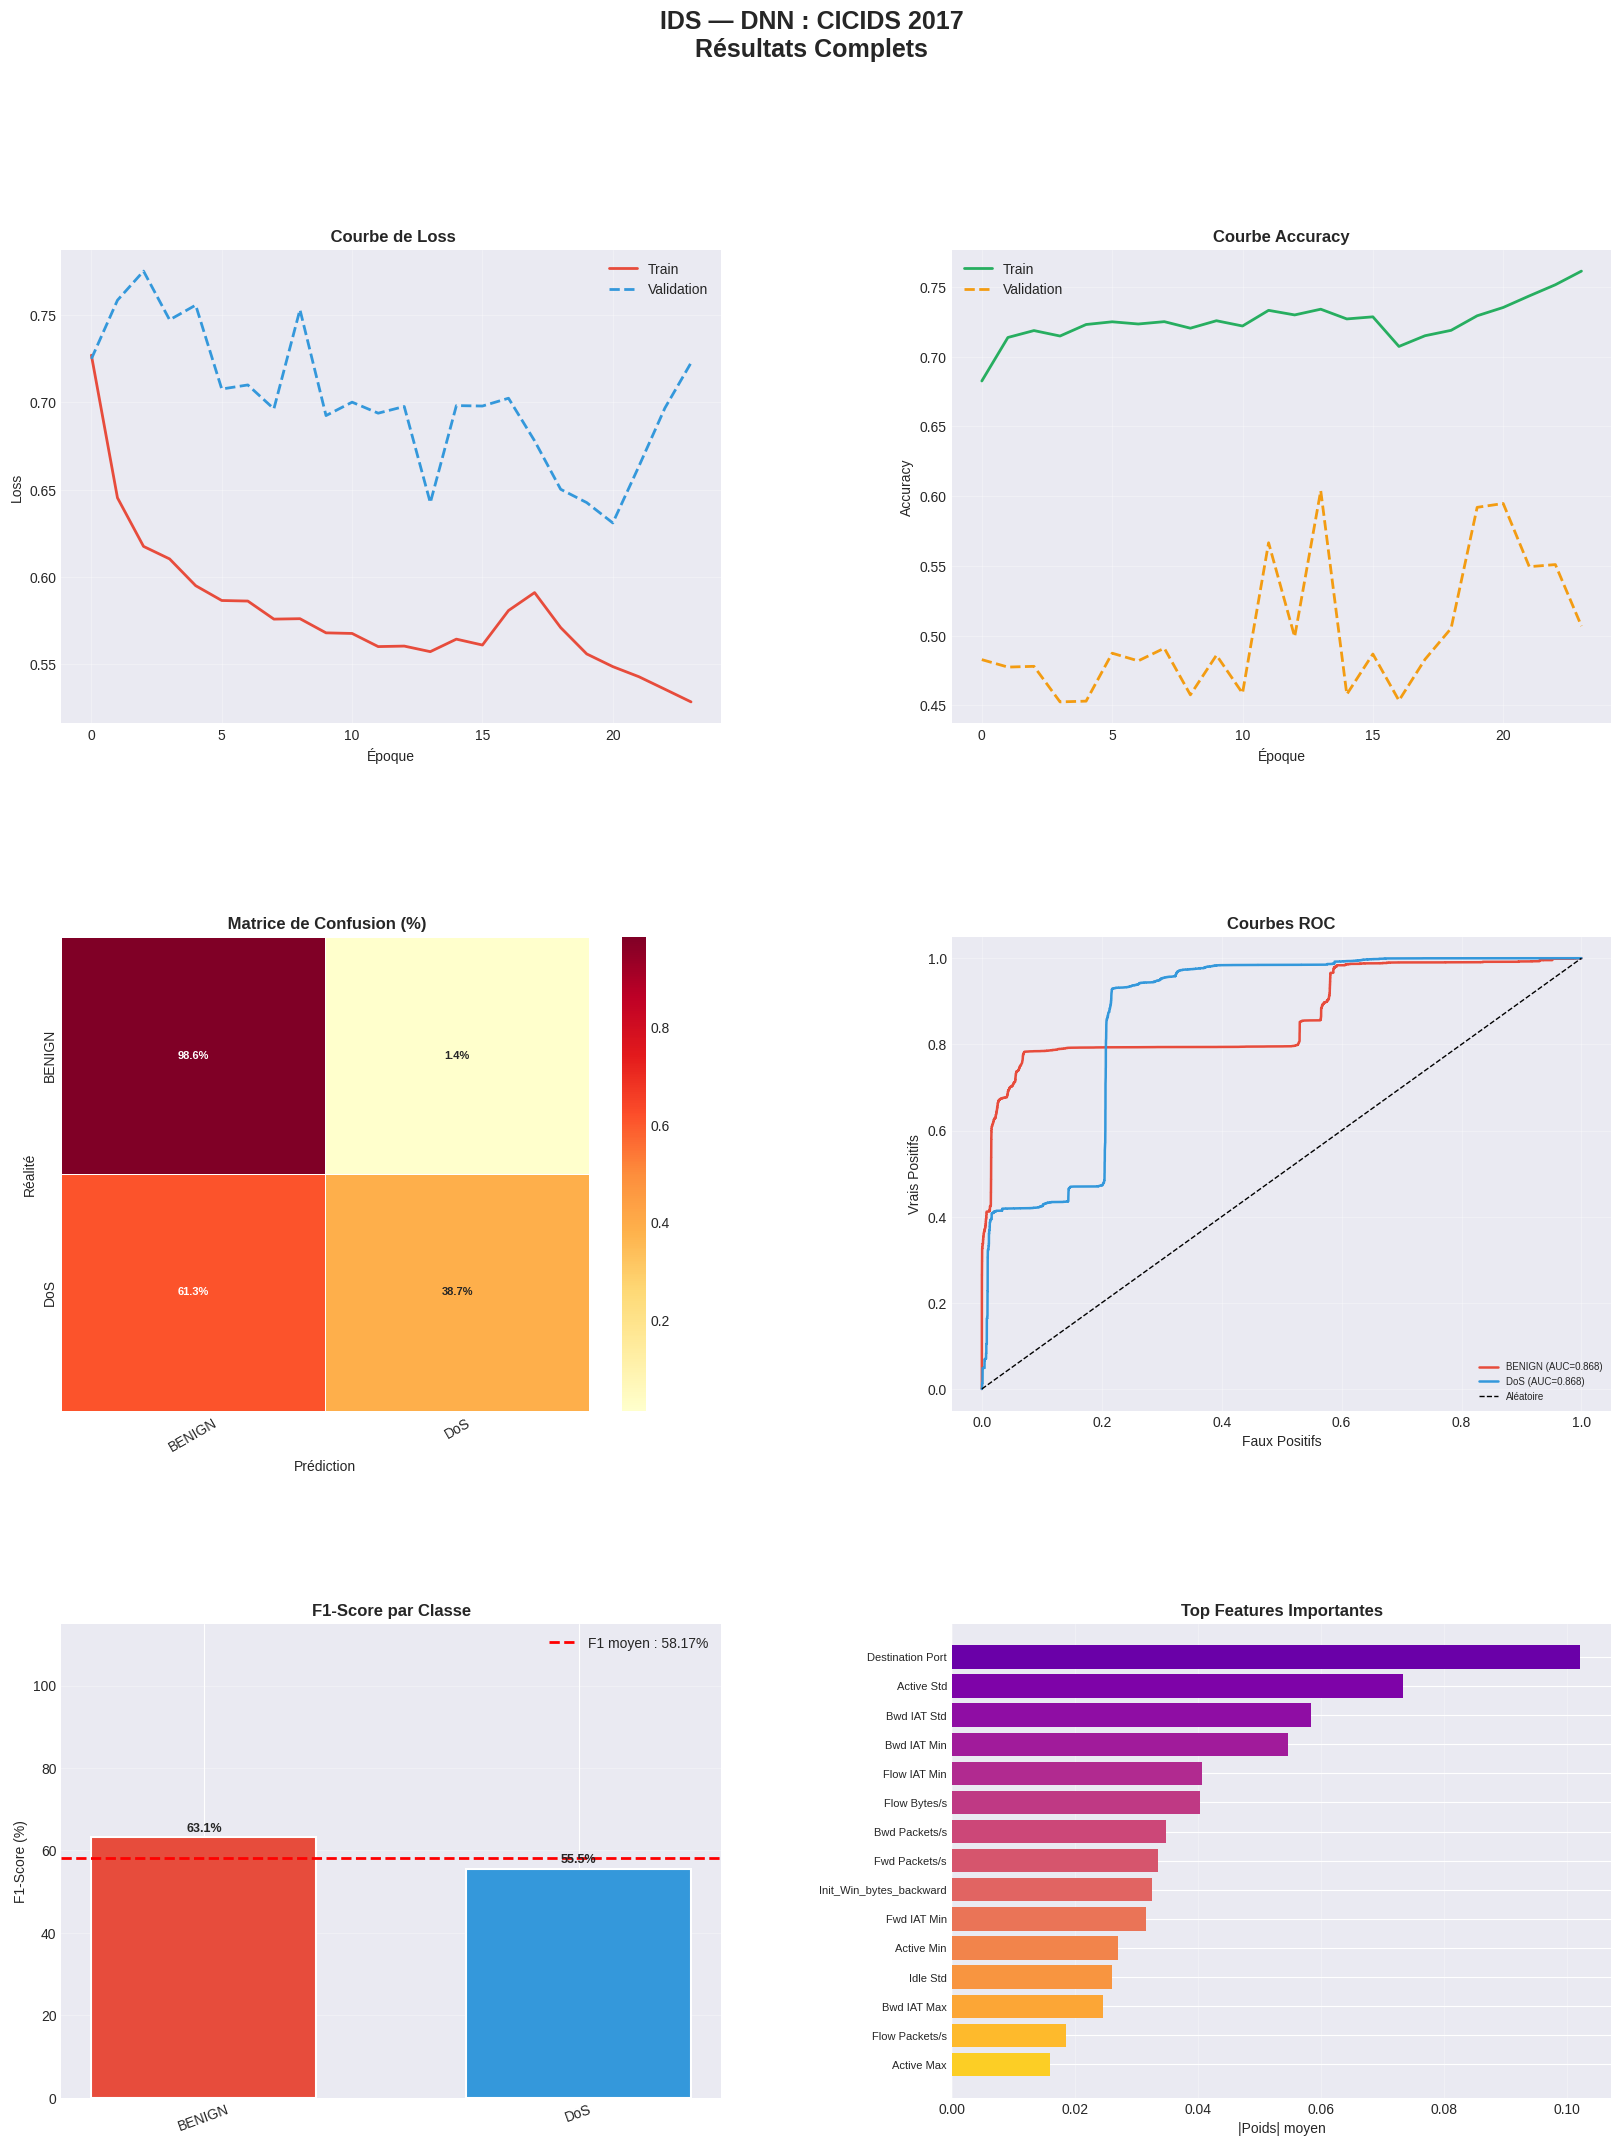

Graphiques est bien sauvegardés : /content/drive/MyDrive/FinalDNN/results/DNN_results.png


In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import gc
from sklearn.metrics import roc_curve, roc_auc_score, f1_score
from tensorflow.keras.utils import to_categorical

plt.style.use('seaborn-v0_8-darkgrid')

PALETTE = ['#e74c3c','#3498db','#27ae60','#f39c12',
           '#8e44ad','#1abc9c','#e67e22']

fig = plt.figure(figsize=(20, 24))
fig.suptitle(
    'IDS — DNN : CICIDS 2017\nRésultats Complets',
    fontsize=18, fontweight='bold'
)
gs = gridspec.GridSpec(3, 2, figure=fig,
                        hspace=0.45, wspace=0.35)

# ── 1. Courbe Loss ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history.history['loss'],
         color='#e74c3c', lw=2, label='Train')
ax1.plot(history.history['val_loss'],
         color='#3498db', lw=2, ls='--', label='Validation')
ax1.set_title(' Courbe de Loss', fontweight='bold', fontsize=12)
ax1.set_xlabel('Époque')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── 2. Courbe Accuracy ───────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history.history['accuracy'],
         color='#27ae60', lw=2, label='Train')
ax2.plot(history.history['val_accuracy'],
         color='#f39c12', lw=2, ls='--', label='Validation')
ax2.set_title('Courbe Accuracy', fontweight='bold', fontsize=12)
ax2.set_xlabel('Époque')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ── 3. Matrice de Confusion ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
cm_norm = CM.astype(float) / CM.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.1%',
    cmap='YlOrRd', ax=ax3,
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    annot_kws={"size": 8, "weight": "bold"}
)
ax3.set_title(' Matrice de Confusion (%)',
               fontweight='bold', fontsize=12)
ax3.set_xlabel('Prédiction')
ax3.set_ylabel('Réalité')
ax3.tick_params(axis='x', rotation=30)

# ── 4. Courbes ROC ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
y_te_bin = to_categorical(y_te, N_CLASSES)
for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, PALETTE)):
    if len(np.unique(y_te_bin[:, i])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_pred_proba[:, i])
    auc_i = roc_auc_score(y_te_bin[:, i], y_pred_proba[:, i])
    ax4.plot(fpr, tpr, color=color, lw=1.8,
             label=f'{cls_name} (AUC={auc_i:.3f})')
ax4.plot([0,1],[0,1], 'k--', lw=1, label='Aléatoire')
ax4.set_title('Courbes ROC', fontweight='bold', fontsize=12)
ax4.set_xlabel('Faux Positifs')
ax4.set_ylabel('Vrais Positifs')
ax4.legend(fontsize=7, loc='lower right')
ax4.grid(True, alpha=0.3)

# ── 5. F1 par classe ─────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
f1_cls = f1_score(y_te, y_pred, average=None,
                   labels=list(range(N_CLASSES)),
                   zero_division=0)
bars = ax5.bar(
    CLASS_NAMES, f1_cls * 100,
    color=[PALETTE[i % len(PALETTE)] for i in range(N_CLASSES)],
    edgecolor='white', linewidth=1.5, width=0.6
)
for bar, val in zip(bars, f1_cls):
    ax5.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val*100:.1f}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
ax5.axhline(y=f1_w*100, color='red', ls='--', lw=2,
             label=f'F1 moyen : {f1_w*100:.2f}%')
ax5.set_title('F1-Score par Classe',
               fontweight='bold', fontsize=12)
ax5.set_ylabel('F1-Score (%)')
ax5.set_ylim(0, 115)
ax5.legend()
ax5.grid(True, axis='y', alpha=0.3)
ax5.tick_params(axis='x', rotation=20)

# ── 6. Importance des features ───────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
try:
    w_first = model_dnn.get_layer('dense_1').get_weights()[0]
    imp     = np.abs(w_first).mean(axis=1)
    n_show  = min(15, len(imp))
    top_idx = np.argsort(imp)[::-1][:n_show]
    top_names = [FEAT_NAMES[i] if i < len(FEAT_NAMES)
                 else f'f{i}' for i in top_idx]
    top_vals  = imp[top_idx]
    colors_bar = plt.cm.plasma(np.linspace(0.2, 0.9, n_show))
    ax6.barh(range(n_show), top_vals, color=colors_bar)
    ax6.set_yticks(range(n_show))
    ax6.set_yticklabels(top_names, fontsize=8)
    ax6.invert_yaxis()
    ax6.set_title('Top Features Importantes',
                   fontweight='bold', fontsize=12)
    ax6.set_xlabel('|Poids| moyen')
    ax6.grid(True, axis='x', alpha=0.3)
except Exception as e:
    ax6.text(0.5, 0.5, f'Non disponible',
             ha='center', va='center',
             transform=ax6.transAxes)

# ── Sauvegarde ───────────────────────────────────────────────────
GRAPH = f'{RESULTS_DIR}/DNN_results.png'
plt.tight_layout()
plt.savefig(GRAPH, dpi=150, bbox_inches='tight')
plt.show()

gc.collect()
print(f"Graphiques est bien sauvegardés : {GRAPH}")

In [11]:
import gc
import tensorflow as tf
import numpy as np
from sklearn.metrics import f1_score

gc.collect()

# Sauvegarder le modèle
FINAL = f'{MODEL_DIR}/DNN_final.keras'
model_dnn.save(FINAL)
print(f"Modèle est bien sauvegardé : {FINAL}")

# Résumé
f1_cls = f1_score(y_te, y_pred, average=None,
                   labels=list(range(N_CLASSES)),
                   zero_division=0)

summary = f"""
{'='*50}
  RÉSUMÉ — IDS basée DNN — CICIDS 2017
{'='*50}
  Accuracy          : {acc*100:.2f} %
  F1-Score Weighted : {f1_w*100:.2f} %
  F1-Score Macro    : {f1_m*100:.2f} %
  AUC-ROC moyen     : {auc_mean:.4f}
  Paramètres        : {model_dnn.count_params():,}
  Features          : {K}
  Classes           : {CLASS_NAMES}
{'─'*50}
  F1 par classe :
"""
for cls, val in zip(CLASS_NAMES, f1_cls):
    bar = '█' * int(val * 20)
    summary += f"  {cls:<12} : {val*100:5.2f}%  {bar}\n"

summary += f"""{'─'*50}
  Architecture :
  Input({K}) → Dense(256)×2 → Dense(128)
             → Dense(64) → Softmax({N_CLASSES})
  Optimiseur : Adam + CosineDecay
  Loss       : CategoricalCrossentropy (smoothing=0.1)
{'='*50}
"""

print(summary)

# Sauvegarder le résumé
with open(f'{RESULTS_DIR}/DNN_summary.txt', 'w') as f:
    f.write(summary)

print(f"Résumé sauvegardé : {RESULTS_DIR}/DNN_summary.txt")
print(f"\n Fichiers dans Drive :")
print(f"   {MODEL_DIR}/DNN_final.keras")
print(f"   {RESULTS_DIR}/DNN_results.png")
print(f"   {RESULTS_DIR}/DNN_summary.txt")

Modèle est bien sauvegardé : /content/drive/MyDrive/FinalDNN/models/DNN_final.keras

  RÉSUMÉ — IDS basée DNN — CICIDS 2017
  Accuracy          : 59.68 %
  F1-Score Weighted : 58.17 %
  F1-Score Macro    : 59.32 %
  AUC-ROC moyen     : 0.8677
  Paramètres        : 120,386
  Features          : 40
  Classes           : ['BENIGN', 'DoS']
──────────────────────────────────────────────────
  F1 par classe :
  BENIGN       : 63.14%  ████████████
  DoS          : 55.50%  ███████████
──────────────────────────────────────────────────
  Architecture :
  Input(40) → Dense(256)×2 → Dense(128)
             → Dense(64) → Softmax(2)
  Optimiseur : Adam + CosineDecay
  Loss       : CategoricalCrossentropy (smoothing=0.1)

Résumé sauvegardé : /content/drive/MyDrive/FinalDNN/results/DNN_summary.txt

 Fichiers dans Drive :
   /content/drive/MyDrive/FinalDNN/models/DNN_final.keras
   /content/drive/MyDrive/FinalDNN/results/DNN_results.png
   /content/drive/MyDrive/FinalDNN/results/DNN_summary.txt
